In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Make plots look nice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

## Function to Generate Emails

In [5]:
def generate_sample_emails(n_samples=1000):
    """
    Generate realistic customer support emails.
    In a real project, you'd load actual data instead.
    """
    
    np.random.seed(42)  # For reproducibility
    
    # Patterns for URGENT emails
    urgent_subjects = [
        'URGENT: Account locked',
        'Cannot access my account!!!',
        'Payment failed - CRITICAL',
        'Security breach detected',
        'Lost all my data - HELP',
        'EMERGENCY: Service completely down',
        'Account hacked - need immediate help',
        'CRITICAL ERROR - Cannot login'
    ]
    
    urgent_bodies = [
        'I cannot access my account and I have an important meeting in 1 hour. This is extremely urgent! Please help ASAP.',
        'My payment failed and now my account is locked. I need this fixed immediately!!!',
        'I think my account has been hacked. All my data is gone. URGENT.',
        'The entire service is down for my team. We cannot work. This is critical!',
        'I lost access to all my files. Need help NOW!',
        'CRITICAL: Cannot login and I have a deadline in 30 minutes!',
    ]
    
    # Patterns for HIGH priority
    high_subjects = [
        'Feature not working properly',
        'Error message when exporting',
        'Bug in the dashboard',
        'Cannot upload files',
        'Integration stopped working',
        'Getting error code 500'
    ]
    
    high_bodies = [
        'I am getting an error when I try to export my data. Can you help me fix this?',
        'The reporting feature stopped working. I need this for my weekly report.',
        'Files are not uploading correctly. This is affecting my workflow.',
        'Getting an error code when I try to access the dashboard.',
        'The integration with Slack is broken. Please look into this.',
    ]
    
    # Patterns for MEDIUM priority
    medium_subjects = [
        'Question about billing',
        'How to use advanced features?',
        'Need clarification on pricing',
        'Setup assistance needed',
        'Best practices question',
        'How do I configure this?'
    ]
    
    medium_bodies = [
        'I have a question about how the billing works for multiple users.',
        'Can you explain how to set up the advanced filters? Thanks.',
        'I need some clarification on the different pricing tiers.',
        'What is the best way to organize my projects in the system?',
        'Could you help me understand how the permissions work?',
    ]
    
    # Patterns for LOW priority
    low_subjects = [
        'Feature suggestion',
        'Feedback on recent update',
        'Enhancement idea',
        'Would be nice to have...',
        'General feedback',
        'Suggestion for improvement'
    ]
    
    low_bodies = [
        'It would be great if you could add a dark mode option in the future.',
        'I have a suggestion for improving the user interface.',
        'Overall the product is good. Here is some feedback for consideration.',
        'Would be nice to have an export to PDF feature someday.',
        'Consider adding keyboard shortcuts. Just a suggestion!',
    ]
    
    # Create emails with realistic distribution
    # Real customer support: 10% Urgent, 25% High, 40% Medium, 25% Low
    
    emails = []
    
    # Generate URGENT emails (10%)
    n_urgent = int(n_samples * 0.10)
    for i in range(n_urgent):
        emails.append({
            'email_id': i + 1,
            'subject': np.random.choice(urgent_subjects),
            'body': np.random.choice(urgent_bodies),
            'priority': 'Urgent'
        })
    
    # Generate HIGH priority emails (25%)
    n_high = int(n_samples * 0.25)
    for i in range(n_high):
        emails.append({
            'email_id': len(emails) + 1,
            'subject': np.random.choice(high_subjects),
            'body': np.random.choice(high_bodies),
            'priority': 'High'
        })
    
    # Generate MEDIUM priority emails (40%)
    n_medium = int(n_samples * 0.40)
    for i in range(n_medium):
        emails.append({
            'email_id': len(emails) + 1,
            'subject': np.random.choice(medium_subjects),
            'body': np.random.choice(medium_bodies),
            'priority': 'Medium'
        })
    
    # Generate LOW priority emails (25%)
    n_low = n_samples - len(emails)  # Remaining
    for i in range(n_low):
        emails.append({
            'email_id': len(emails) + 1,
            'subject': np.random.choice(low_subjects),
            'body': np.random.choice(low_bodies),
            'priority': 'Low'
        })
    
    # Shuffle so they're not ordered by priority
    np.random.shuffle(emails)
    
    # Re-assign email IDs after shuffling
    for i, email in enumerate(emails):
        email['email_id'] = i + 1
    
    return pd.DataFrame(emails)

# Generate the data
print("Generating sample emails...")
df = generate_sample_emails(1000)

# Save it
df.to_csv('../data/raw/emails.csv', index=False)

print(f"✅ Generated {len(df)} emails")
print(f"✅ Saved to data/raw/emails.csv")
print(f"\nDataset shape: {df.shape}")

Generating sample emails...
✅ Generated 1000 emails
✅ Saved to data/raw/emails.csv

Dataset shape: (1000, 4)


In [6]:
print("First 5 emails:")
print("="*80)
df.head()

First 5 emails:


,email_id,subject,body,priority
0,1,Feature not working properly,I am getting an error when I try to export my ...,High
1,2,Best practices question,What is the best way to organize my projects i...,Medium
2,3,How do I configure this?,What is the best way to organize my projects i...,Medium
3,4,Feature not working properly,Files are not uploading correctly. This is aff...,High
4,5,Account hacked - need immediate help,The entire service is down for my team. We can...,Urgent


## Read some actual examples

In [9]:
print("Let's read some actual emails to understand what we're working with:\n")

for priority in ['Urgent', 'High', 'Medium', 'Low']:
    print("-"*80)
    print(f"📧 {priority.upper()} PRIORITY EMAIL EXAMPLE")
    
    # Get one random example
    sample = df[df['priority'] == priority].sample(1).iloc[0]
    
    print(f"\n📌 Subject: {sample['subject']}")
    print(f"📝 Body:\n{sample['body']}\n")

Let's read some actual emails to understand what we're working with:

--------------------------------------------------------------------------------
📧 URGENT PRIORITY EMAIL EXAMPLE

📌 Subject: CRITICAL ERROR - Cannot login
📝 Body:
The entire service is down for my team. We cannot work. This is critical!

--------------------------------------------------------------------------------
📧 HIGH PRIORITY EMAIL EXAMPLE

📌 Subject: Integration stopped working
📝 Body:
The integration with Slack is broken. Please look into this.

--------------------------------------------------------------------------------
📧 MEDIUM PRIORITY EMAIL EXAMPLE

📌 Subject: Question about billing
📝 Body:
Can you explain how to set up the advanced filters? Thanks.

--------------------------------------------------------------------------------
📧 LOW PRIORITY EMAIL EXAMPLE

📌 Subject: Would be nice to have...
📝 Body:
I have a suggestion for improving the user interface.



## Basic Information

In [10]:
print("Dataset Information:")
print("-"*50)
print(f"Total emails: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Column names: {list(df.columns)}")

print("\n" + "="*50)
print("Data types:")
print(df.dtypes)

print("\n" + "="*50)
print("Missing values:")
print(df.isnull().sum())

Dataset Information:
--------------------------------------------------
Total emails: 1000
Number of columns: 4
Column names: ['email_id', 'subject', 'body', 'priority']

Data types:
email_id     int64
subject     object
body        object
priority    object
dtype: object

Missing values:
email_id    0
subject     0
body        0
priority    0
dtype: int64


## Ensuring Priority Distribution

In [11]:
print("Priority Distribution:")
print("-"*50)

# Count each priority
counts = df['priority'].value_counts()
print("\nCounts:")
print(counts)

print("\nPercentages:")
percentages = df['priority'].value_counts(normalize=True) * 100
for priority, pct in percentages.items():
    print(f"{priority:10s}: {pct:5.1f}%")

Priority Distribution:
--------------------------------------------------

Counts:
priority
Medium    400
High      250
Low       250
Urgent    100
Name: count, dtype: int64

Percentages:
Medium    :  40.0%
High      :  25.0%
Low       :  25.0%
Urgent    :  10.0%


## Visual of Priority Distribution

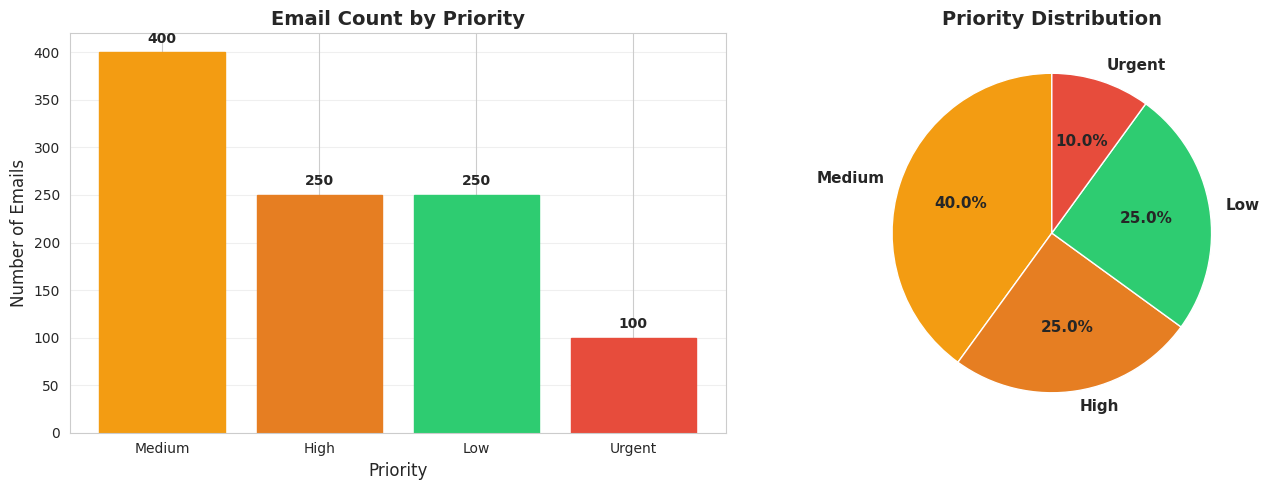


⚠️  OBSERVATION: Class Imbalance Detected!
   Urgent emails are only ~10% of the data
   This means we need to use 'class_weight=balanced' when training


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = {'Urgent': '#e74c3c', 'High': '#e67e22', 'Medium': '#f39c12', 'Low': '#2ecc71'}
priority_counts = df['priority'].value_counts()
bars = axes[0].bar(priority_counts.index, priority_counts.values)

# Color each bar
for bar, priority in zip(bars, priority_counts.index):
    bar.set_color(colors[priority])

axes[0].set_title('Email Count by Priority', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Priority', fontsize=12)
axes[0].set_ylabel('Number of Emails', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, (priority, count) in enumerate(priority_counts.items()):
    axes[0].text(i, count + 10, str(count), ha='center', fontweight='bold')

# Pie chart
pie_colors = [colors[p] for p in priority_counts.index]
axes[1].pie(priority_counts.values, labels=priority_counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Priority Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n⚠️  OBSERVATION: Class Imbalance Detected!")
print("   Urgent emails are only ~10% of the data")
print("   This means we need to use 'class_weight=balanced' when training")

## Text Analysis

In [15]:
# Calculate lengths
df['subject_length'] = df['subject'].str.len()
df['body_length'] = df['body'].str.len()
df['word_count'] = df['body'].str.split().str.len()

print("Text Length Statistics:")
print("-"*50)
print(df[['subject_length', 'body_length', 'word_count']].describe())

print("\n\nBy Priority:")
print("-"*50)
print(df.groupby('priority')[['subject_length', 'body_length', 'word_count']].mean())

Text Length Statistics:
--------------------------------------------------
       subject_length  body_length  word_count
count     1000.000000  1000.000000  1000.00000
mean        23.898000    62.314000    11.33800
std          4.241885     9.871416     2.75415
min         16.000000    45.000000     7.00000
25%         22.000000    57.000000     9.00000
50%         24.000000    59.000000    11.00000
75%         27.000000    68.000000    12.00000
max         36.000000   113.000000    21.00000


By Priority:
--------------------------------------------------
          subject_length  body_length  word_count
priority                                         
High             24.0400       66.664     12.4280
Low              20.6920       59.280     10.4480
Medium           24.9025       58.965     10.5825
Urgent           27.5400       72.420     13.8600
